# ISACA Scholarship Competition 2025
### Taylor Peterson
### Python Scraping Function & Analysis in Google Colab

In [ ]:
!pip install requests beautifulsoup4

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
# Define function to get search results
def search_duckduckgo(query, num_results=100):
    import urllib.parse
    headers = {"User-Agent": "Mozilla/5.0"}
    search_url = f"https://html.duckduckgo.com/html/?q={query}"

    response = requests.get(search_url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    results = []
    for link in soup.find_all('a'):
        href = link.get('href')
        text = link.get_text(strip=True)
        if href and "http" in href and text:
            # Decode redirect link (adjusted 7 times)
            real_url = urllib.parse.unquote(href.split("uddg=")[-1].split("&")[0]) if "uddg=" in href else href
            results.append({"title": text, "url": real_url})
        if len(results) >= num_results:
            break

    return pd.DataFrame(results)

In [ ]:
queries = {
    "burp suite hack": "Burp Hack",
    "overwatch widget hack": "Overwatch Widget Hack",
    "burp suite price manipulation": "Burp Price Manipulation",
    "widget AI assistant exploit": "Widget Exploit",
    "overwatch hacker leak twitter": "Overwatch Twitter Leak",
    "widget vulnerability leak": "Widget Vulnerability Leak",
    "dark web leak AI assistant": "Dark Web Leak AI Assistant"
}

In [ ]:
dfs = {}

for q, label in queries.items():
    print(f"Running: {label}")
    df = search_duckduckgo(q, num_results=100)
    df["label"] = label
    dfs[label] = df

Running: Burp Hack
Running: Overwatch Widget Hack
Running: Burp Price Manipulation
Running: Widget Exploit
Running: Overwatch Twitter Leak
Running: Widget Vulnerability Leak
Running: Dark Web Leak AI Assistant


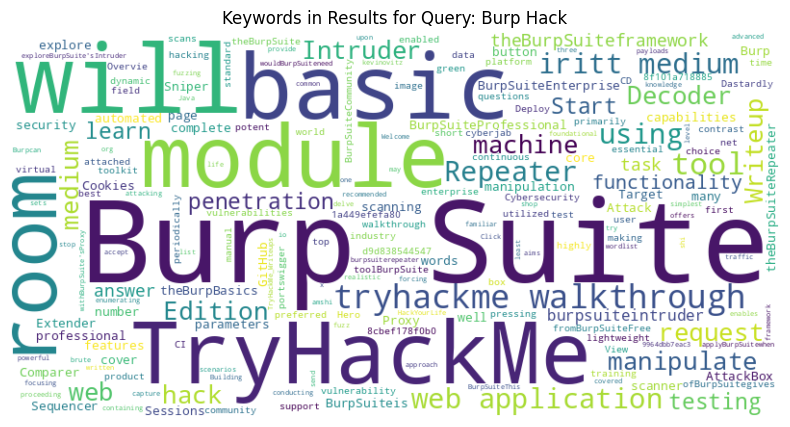

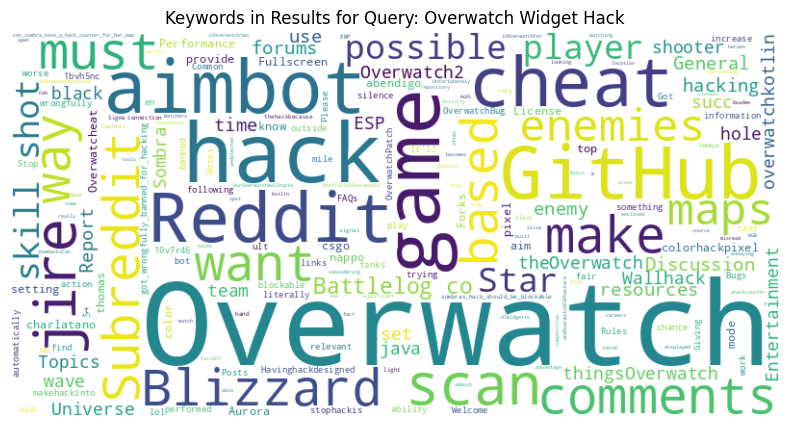

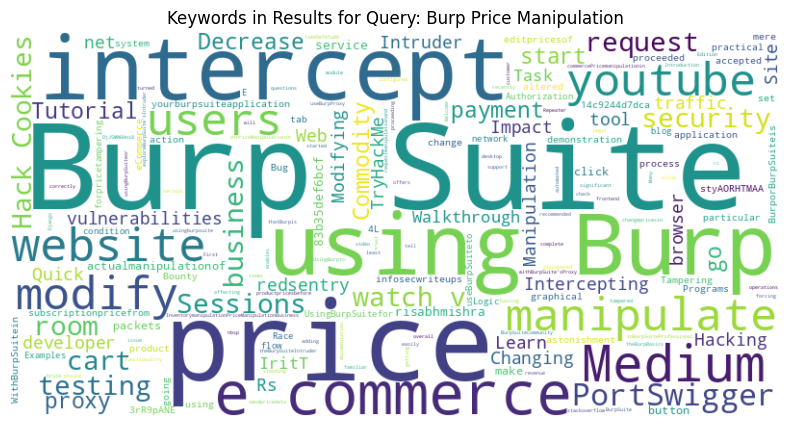

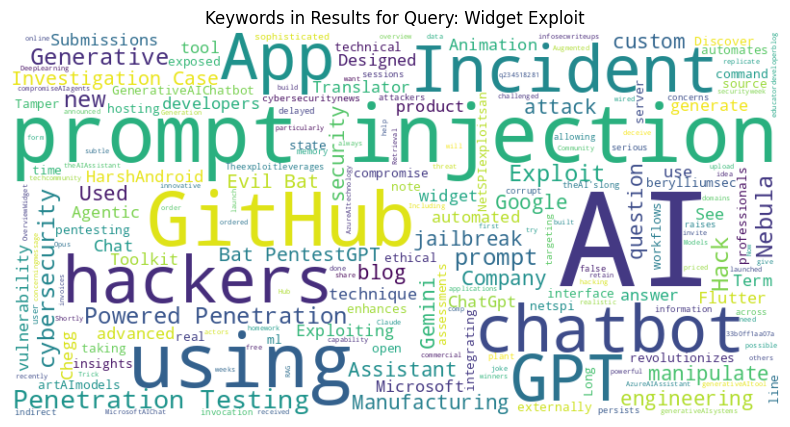

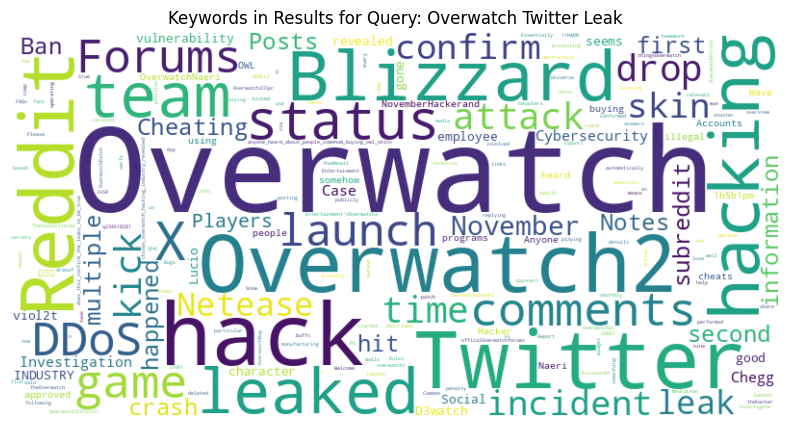

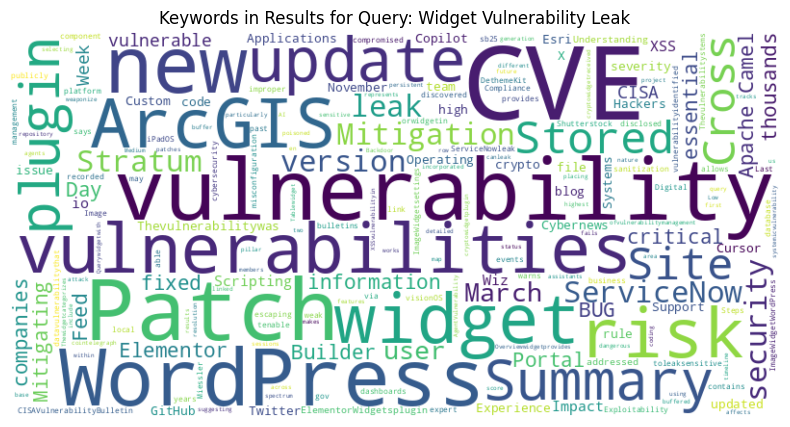

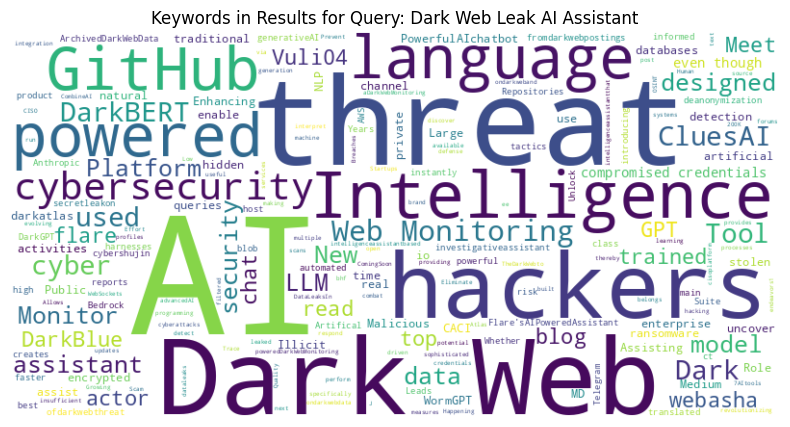

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label, df in dfs.items():
    text_blob = ' '.join(df['title'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Keywords in Results for Query: {label}")
    plt.show()

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    # -1 = negative, 1 = positive
    return TextBlob(text).sentiment.polarity

for label, df in dfs.items():
    dfs[label]['sentiment'] = dfs[label]['title'].apply(get_sentiment)

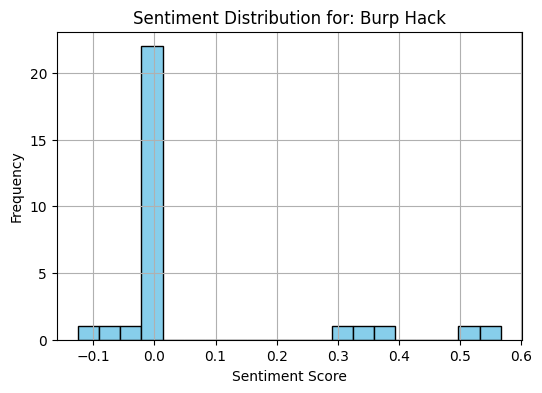

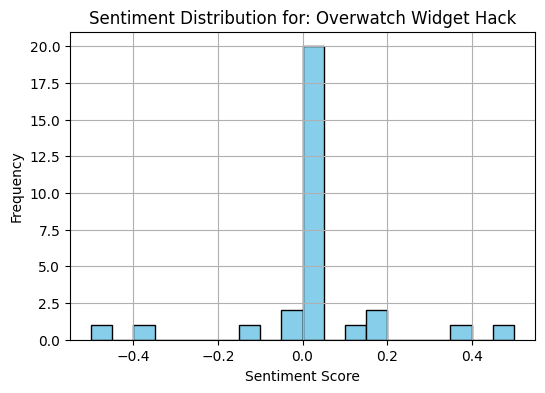

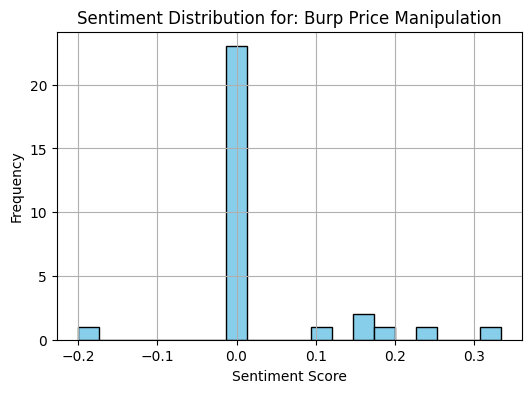

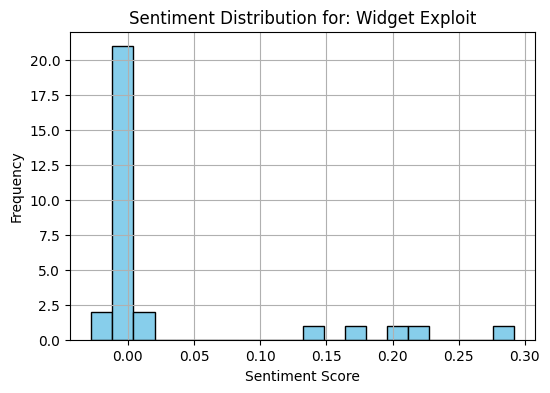

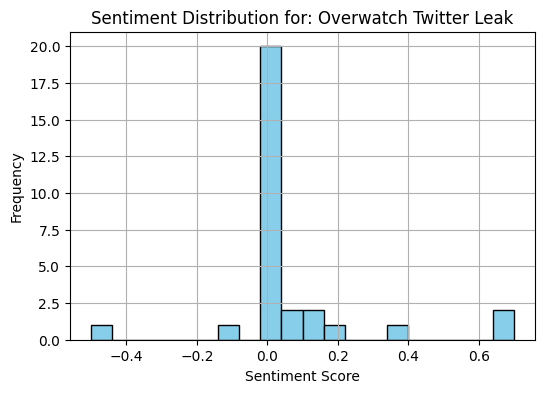

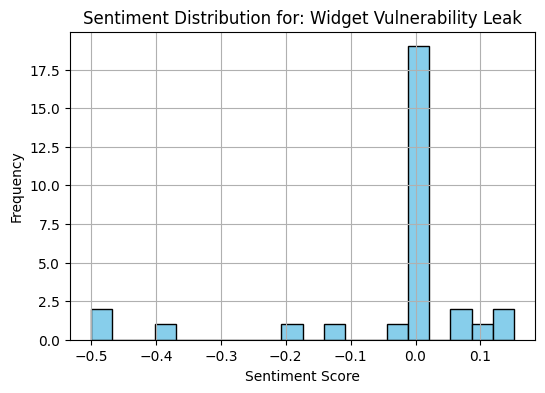

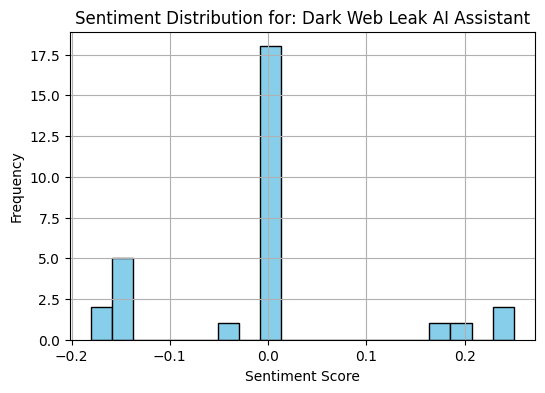

In [ ]:
for label, df in dfs.items():
    plt.figure(figsize=(6, 4))
    plt.hist(df['sentiment'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Sentiment Distribution for: {label}")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

In [ ]:
summary = pd.DataFrame({
    "Query": list(dfs.keys()),
    "Results Found": [len(df) for df in dfs.values()]
})
display(summary)

,Query,Results Found
0,Burp Hack,30
1,Overwatch Widget Hack,30
2,Burp Price Manipulation,30
3,Widget Exploit,30
4,Overwatch Twitter Leak,30
5,Widget Vulnerability Leak,30
6,Dark Web Leak AI Assistant,30


In [ ]:
combined_df = pd.concat(dfs.values(), ignore_index=True)
display(combined_df.head(15))

,title,url,label,sentiment
0,Using Burp to Hack Cookies and Manipulate Sess...,https://portswigger.net/support/using-burp-to-...,Burp Hack,0.000000
1,portswigger.net/support/using-burp-to-hack-coo...,https://portswigger.net/support/using-burp-to-...,Burp Hack,0.000000
2,BurpSuiteEnterprise Edition The enterprise-ena...,https://portswigger.net/support/using-burp-to-...,Burp Hack,0.500000
3,Burp Suite - TryHackMe,https://tryhackme.com/module/learn-burp-suite,Burp Hack,0.000000
4,tryhackme.com/module/learn-burp-suite,https://tryhackme.com/module/learn-burp-suite,Burp Hack,0.000000
5,BurpSuiteis the industry standard tool for web...,https://tryhackme.com/module/learn-burp-suite,Burp Hack,0.000000
6,Burp Suite: The Basics TryHackMe Writeup - Medium,https://medium.com/@cyberjab/burp-suite-the-ba...,Burp Hack,0.000000
7,medium.com/@cyberjab/burp-suite-the-basics-try...,https://medium.com/@cyberjab/burp-suite-the-ba...,Burp Hack,0.000000
8,Hero image of the toolBurpSuite. This is a wri...,https://medium.com/@cyberjab/burp-suite-the-ba...,Burp Hack,0.000000
9,Burp Suite: The Basics — TryHackMe Walkthrough...,https://iritt.medium.com/burp-suite-the-basics...,Burp Hack,0.000000


In [ ]:
combined_df.tail()

,title,url,label,sentiment
205,arstechnica.com/security/2024/03/hackers-can-r...,https://arstechnica.com/security/2024/03/hacke...,Dark Web Leak AI Assistant,0.000000
206,Hackers can read privateAI-assistantchats even...,https://arstechnica.com/security/2024/03/hacke...,Dark Web Leak AI Assistant,0.000000
207,How AI is Being Used to Monitor the Dark Web |...,https://www.webasha.com/blog/how-ai-is-being-u...,Dark Web Leak AI Assistant,-0.150000
208,www.webasha.com/blog/how-ai-is-being-used-to-m...,https://www.webasha.com/blog/how-ai-is-being-u...,Dark Web Leak AI Assistant,0.000000
209,Thedarkwebis a hidden part of the internet use...,https://www.webasha.com/blog/how-ai-is-being-u...,Dark Web Leak AI Assistant,-0.033333


In [ ]:
combined_df['label'].value_counts()

,count
label,
Burp Hack,30
Overwatch Widget Hack,30
Burp Price Manipulation,30
Widget Exploit,30
Overwatch Twitter Leak,30
Widget Vulnerability Leak,30
Dark Web Leak AI Assistant,30


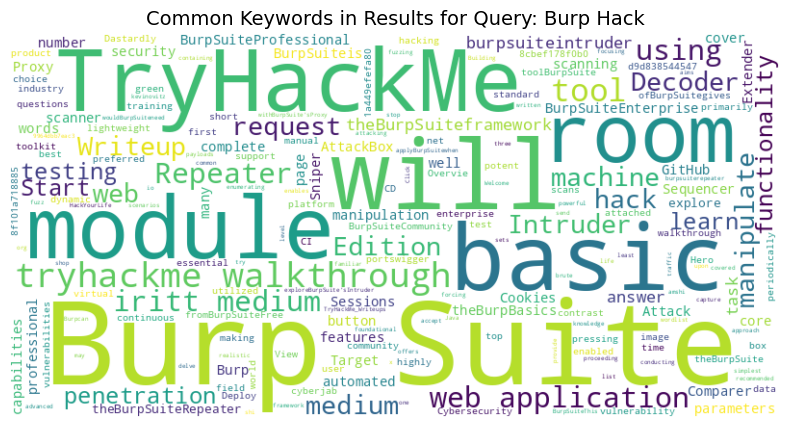

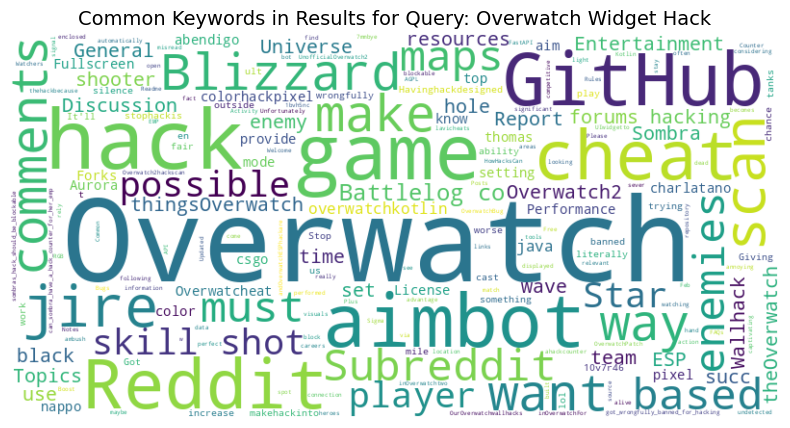

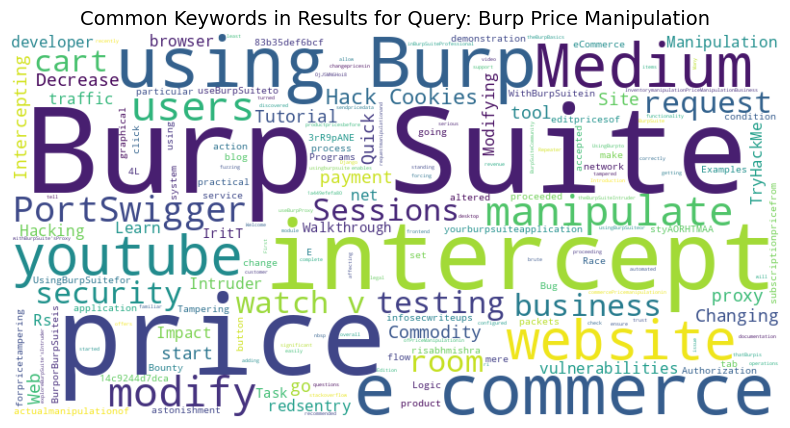

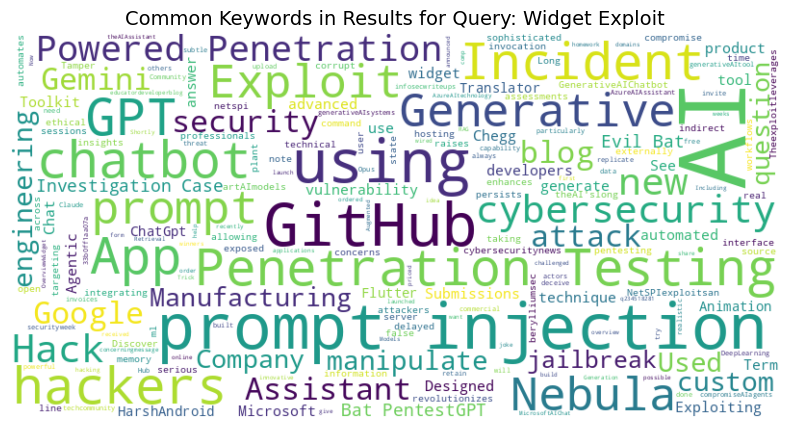

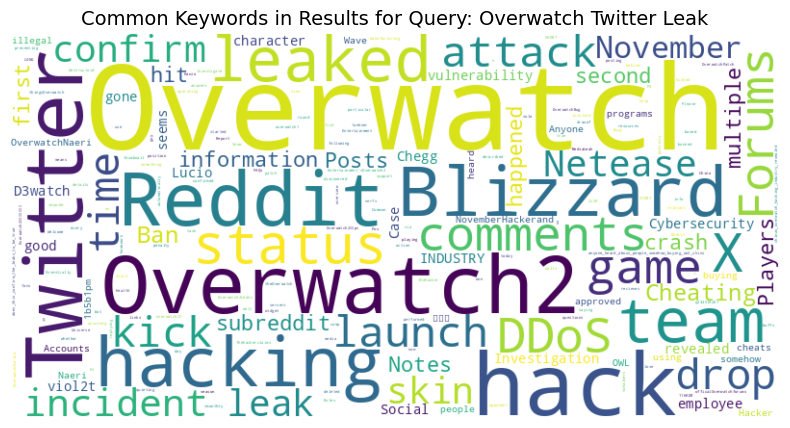

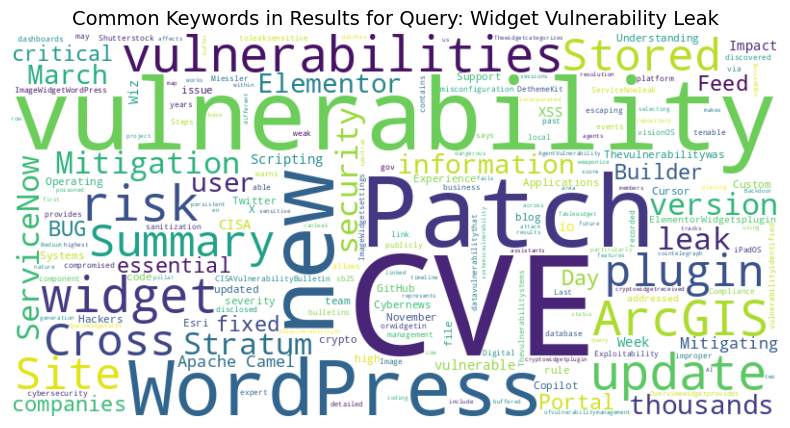

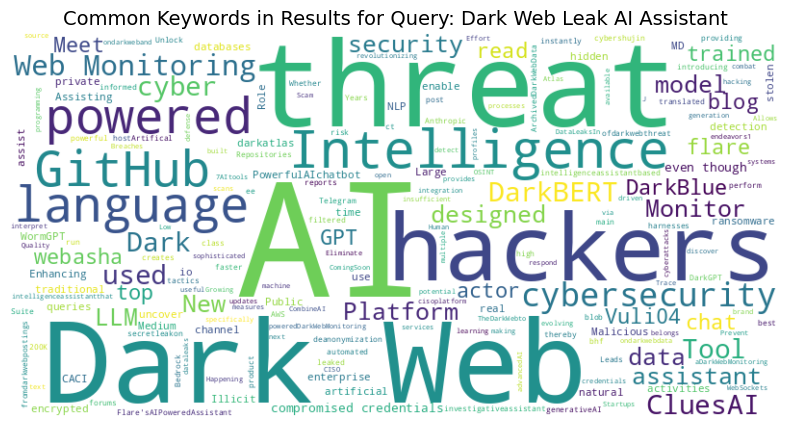

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label in combined_df['label'].unique():
    text_blob = ' '.join(combined_df[combined_df['label'] == label]['title'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Common Keywords in Results for Query: {label}", fontsize=14)
    plt.show()

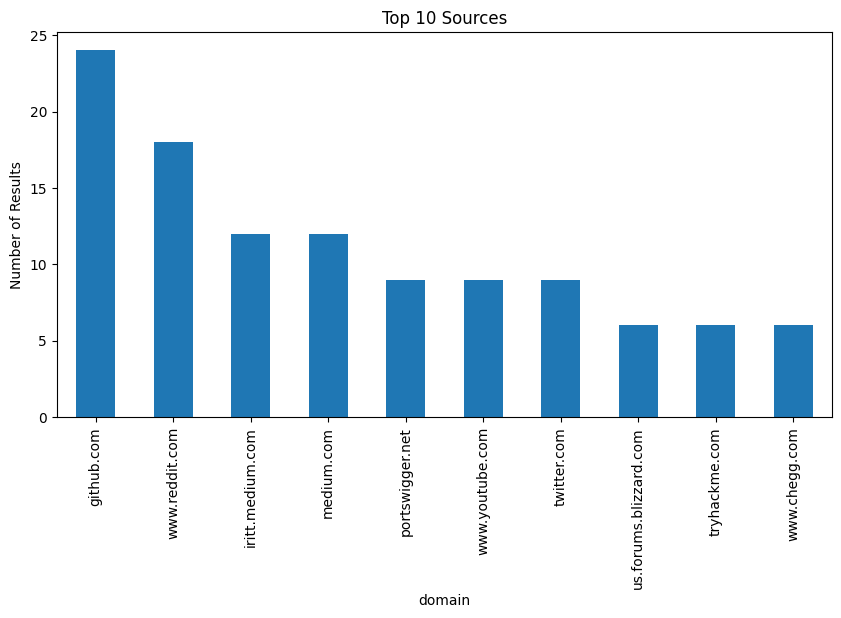

In [ ]:
from urllib.parse import urlparse

combined_df['domain'] = combined_df['url'].apply(lambda x: urlparse(x).netloc)
combined_df['domain'].value_counts().head(10).plot(kind='bar', figsize=(10,5), title='Top 10 Sources')
plt.ylabel("Number of Results")
plt.show()

In [ ]:
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm

def extract_page_content(url):
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, "html.parser")

        paragraphs = soup.find_all("p")
        text = ' '.join([p.get_text() for p in paragraphs])

        return text.strip() if text else None
    except Exception as e:
        return None

content_list = []
label_list = []

for label in combined_df['label'].unique():
    subset = combined_df[combined_df['label'] == label].head(30)
    for url in tqdm(subset['url'], desc=f"Scraping {label}"):
        content_list.append(extract_page_content(url))
        label_list.append(label)

scraped_df = pd.DataFrame({'label': label_list, 'content': content_list})
scraped_df = scraped_df.dropna()


Scraping Burp Hack: 100%|██████████| 30/30 [00:22<00:00,  1.32it/s]

Scraping Overwatch Widget Hack: 100%|██████████| 30/30 [00:09<00:00,  3.17it/s]

Scraping Burp Price Manipulation: 100%|██████████| 30/30 [00:25<00:00,  1.17it/s]

Scraping Widget Exploit: 100%|██████████| 30/30 [00:18<00:00,  1.66it/s]

Scraping Overwatch Twitter Leak: 100%|██████████| 30/30 [00:09<00:00,  3.33it/s]

Scraping Widget Vulnerability Leak: 100%|██████████| 30/30 [00:22<00:00,  1.36it/s]

Scraping Dark Web Leak AI Assistant: 100%|██████████| 30/30 [00:22<00:00,  1.35it/s]


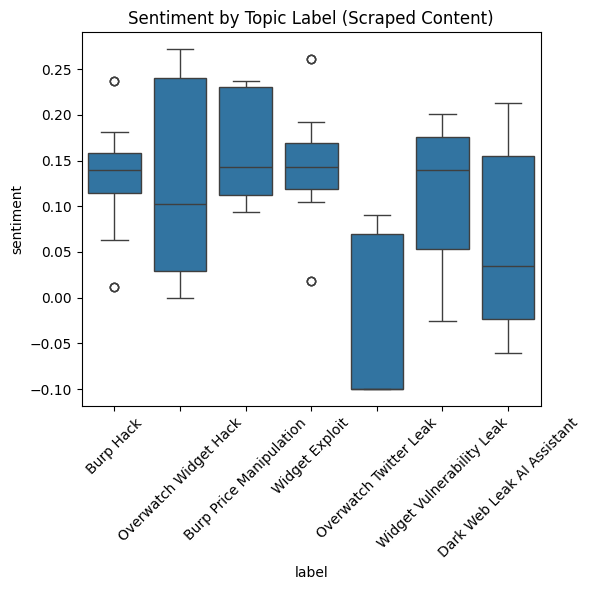

In [ ]:
from textblob import TextBlob

scraped_df['sentiment'] = scraped_df['content'].apply(lambda x: TextBlob(x).sentiment.polarity)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.boxplot(data=scraped_df, x='label', y='sentiment')
plt.title('Sentiment by Topic Label (Scraped Content)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-48-cb9d6aac46f1>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


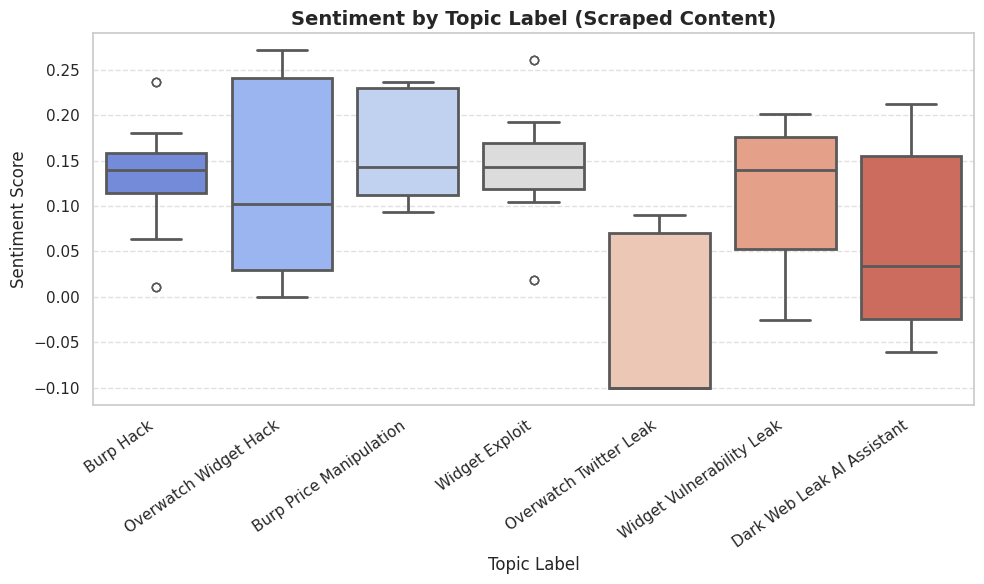

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=scraped_df,
    x='label',
    y='sentiment',
    palette='coolwarm',
    linewidth=2
)

plt.title('Sentiment by Topic Label (Scraped Content)', fontsize=14, weight='bold')
plt.xlabel('Topic Label', fontsize=12)
plt.ylabel('Sentiment Score', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<ipython-input-49-605781aa3fee>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


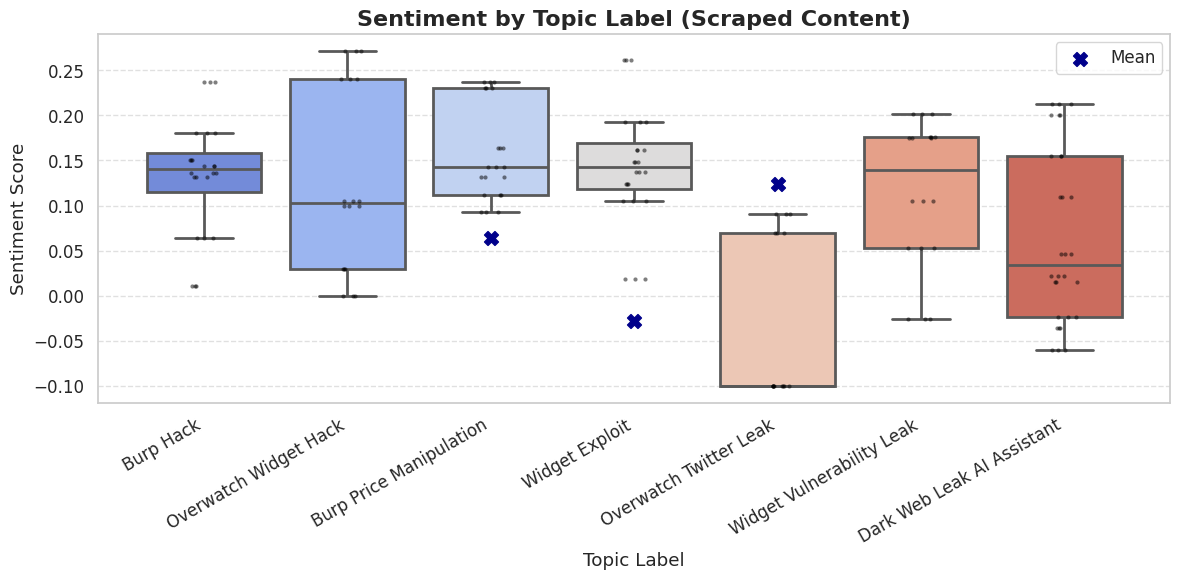

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=scraped_df,
    x='label',
    y='sentiment',
    palette='coolwarm',
    linewidth=2,
    showfliers=False
)

sns.stripplot(
    data=scraped_df,
    x='label',
    y='sentiment',
    color='black',
    size=3,
    alpha=0.5,
    jitter=True,
    ax=ax
)

mean_values = scraped_df.groupby('label')['sentiment'].mean()

for i, mean in enumerate(mean_values):
    ax.scatter(i, mean, marker='X', color='darkblue', s=100, label='Mean' if i == 0 else "")

plt.title('Sentiment by Topic Label (Scraped Content)', fontsize=16, weight='bold')
plt.xlabel('Topic Label')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
if 'Mean' in labels:
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

<ipython-input-50-436f098f6f21>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=scraped_df, x='label', y='sentiment', palette='pastel', showfliers=True)


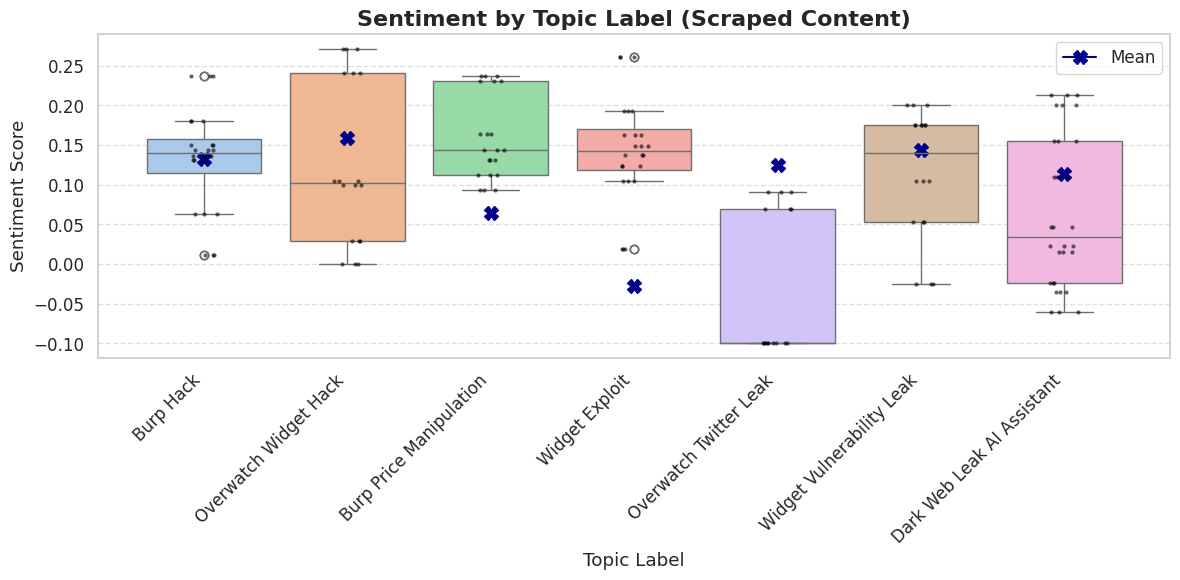

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=scraped_df, x='label', y='sentiment', palette='pastel', showfliers=True)
sns.stripplot(data=scraped_df, x='label', y='sentiment', color='black', size=3, alpha=0.6, ax=ax)

mean_values = scraped_df.groupby('label')['sentiment'].mean()

for i, mean in enumerate(mean_values):
    ax.plot(i, mean, marker='X', color='darkblue', markersize=10, label='Mean' if i == 0 else "")

ax.set_title("Sentiment by Topic Label (Scraped Content)", fontsize=16, weight='bold')
ax.set_xlabel("Topic Label")
ax.set_ylabel("Sentiment Score")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.tight_layout()
plt.show()


<ipython-input-51-0cf90ddd00dc>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=scraped_df, x='label', y='sentiment', order=ordered_labels, palette='Set2')


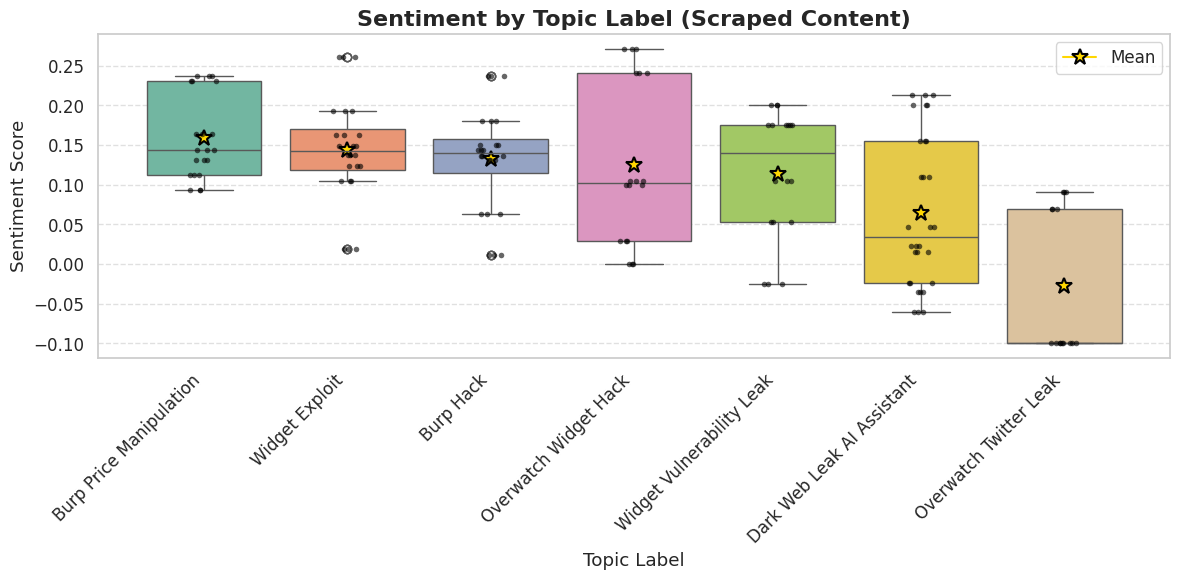

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Group by label and calc mean
mean_values = scraped_df.groupby('label')['sentiment'].mean()
ordered_labels = mean_values.sort_values(ascending=False).index
mean_values = mean_values.reindex(ordered_labels)

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=scraped_df, x='label', y='sentiment', order=ordered_labels, palette='Set2')
sns.stripplot(data=scraped_df, x='label', y='sentiment', order=ordered_labels,
              color='black', size=4, jitter=True, alpha=0.6)

# Plot mean values
labeled = False

for i, mean in enumerate(mean_values):
    ax.plot(i, mean,
            marker='*',
            color='gold',
            markersize=12,
            markeredgecolor='black',
            markeredgewidth=1.5,
            label='Mean' if not labeled else "")
    labeled = True

plt.title("Sentiment by Topic Label (Scraped Content)", fontsize=16, weight='bold')
plt.xlabel("Topic Label")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


<ipython-input-52-af12f8168856>:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')
<ipython-input-52-af12f8168856>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=scraped_df, x='label', y='sentiment', order=ordered_labels, palette='Set2')


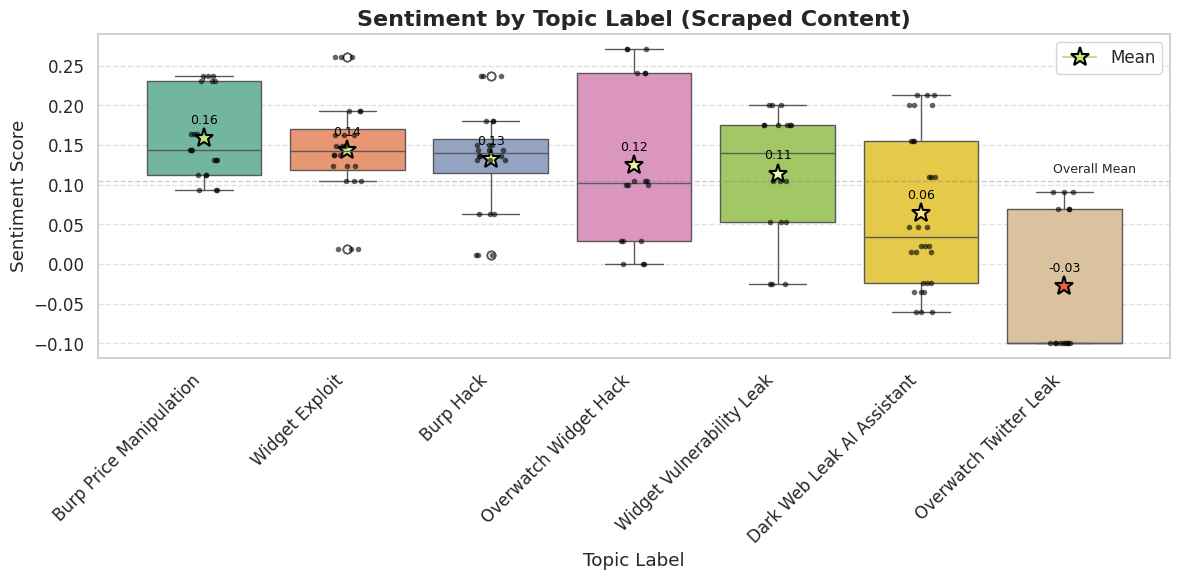

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Group by label and calculate mean
mean_values = scraped_df.groupby('label')['sentiment'].mean()
ordered_labels = mean_values.sort_values(ascending=False).index
mean_values = mean_values.reindex(ordered_labels)

# Color map based on sentiment polarity
norm = mcolors.Normalize(vmin=-0.1, vmax=0.3)
cmap = cm.get_cmap('RdYlGn')

# Plot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=scraped_df, x='label', y='sentiment', order=ordered_labels, palette='Set2')
sns.stripplot(data=scraped_df, x='label', y='sentiment', order=ordered_labels,
              color='black', size=4, jitter=True, alpha=0.6)

for i, mean in enumerate(mean_values):
    ax.plot(i, mean,
            marker='*',
            color=cmap(norm(mean)),
            markersize=14,
            markeredgecolor='black',
            markeredgewidth=1.5,
            label='Mean' if i == 0 else "")

    ax.text(i, mean + 0.015, f"{mean:.2f}", ha='center', va='bottom', fontsize=9, color='black')

overall_mean = scraped_df['sentiment'].mean()
plt.axhline(y=overall_mean, color='gray', linestyle='--', linewidth=1, alpha=0.4)
plt.text(len(ordered_labels) - 0.5, overall_mean + 0.01, 'Overall Mean', ha='right', fontsize=9)

plt.title("Sentiment by Topic Label (Scraped Content)", fontsize=16, weight='bold')
plt.xlabel("Topic Label")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

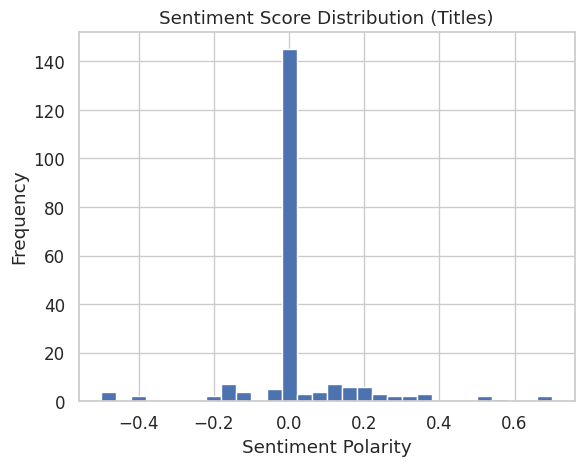

In [ ]:
all_titles_df = pd.concat(dfs.values(), ignore_index=True)
all_titles_df['sentiment'].hist(bins=30)
plt.title("Sentiment Score Distribution (Titles)")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()